# Importing

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import seaborn as sns

data_path = '../data/PD-L1/'

# Format Data

In [3]:
def create_mars_intervals(df, interval_length, max_obs_time=None):
    """
    Create interval-based rows for MARS algorithm from reconstructed survival data,
    with an optional observation horizon that censors events after max_obs_time.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: time, status, treat, Group, curve
    interval_length : float
        Length of each time interval (e.g., 6 for 6-month intervals)
    max_obs_time : float or None, default None
        Maximum observation time. Times beyond this are censored at max_obs_time.
        If None, uses df['time'].max().
    
    Returns:
    --------
    pandas.DataFrame
        Expanded DataFrame with one row per patient per interval
    """
    # Validate input DataFrame
    required_cols = ['time', 'status', 'treat', 'Group', 'curve']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    if interval_length <= 0:
        raise ValueError("interval_length must be positive.")
    
    # Determine observation horizon
    data_max_time = float(df['time'].max())
    if max_obs_time is None:
        obs_horizon = data_max_time
    else:
        if max_obs_time <= 0:
            raise ValueError("max_obs_time must be positive.")
        obs_horizon = float(max_obs_time)

    # Number of intervals and breaks under the observation horizon
    n_intervals = int(np.ceil(obs_horizon / interval_length))
    interval_breaks = [i * interval_length for i in range(n_intervals + 1)]
    interval_breaks[-1] = max(interval_breaks[-1], obs_horizon)  # ensure last interval covers horizon

    print(f"Creating {n_intervals} intervals of length {interval_length} with horizon={obs_horizon:.4f}")
    print(f"Interval breaks: {interval_breaks[:5]}{'...' if len(interval_breaks) > 5 else ''}")

    expanded_rows = []

    # Process each patient
    for idx, row in df.iterrows():
        original_time = float(row['time'])
        original_status = int(row['status'])

        # Apply administrative censoring at obs_horizon
        patient_time = min(original_time, obs_horizon)
        # If event occurs after the horizon, it becomes censored at the horizon
        patient_status = int(original_status == 1 and original_time <= obs_horizon)

        # Determine which intervals this patient contributes to
        for interval_idx in range(n_intervals):
            interval_start = interval_breaks[interval_idx]
            interval_end = interval_breaks[interval_idx + 1]

            # Skip if patient doesn't contribute to this interval
            if patient_time <= interval_start:
                break

            # Calculate exposure time in this interval
            exposure_start = max(interval_start, 0.0)
            exposure_end = min(interval_end, patient_time)
            exposure_time = max(0.0, exposure_end - exposure_start)

            # Event indicator for this interval
            event_in_interval = (interval_start < patient_time <= interval_end) and (patient_status == 1)

            expanded_rows.append({
                'patient_id': idx,
                'interval': interval_idx + 1,           # 1-indexed
                'interval_start': interval_start,
                'interval_end': interval_end,
                'exposure_time': exposure_time,
                'event': int(event_in_interval),
                'treat': row['treat'],
                'Group': row['Group'],
                'original_time': original_time,
                'original_status': original_status,
                'censored_at_horizon': int(original_time > obs_horizon)
            })

    result_df = pd.DataFrame(expanded_rows)

    # Summary statistics (respecting horizon censoring)
    total_events_within_horizon = int(((df['time'] <= obs_horizon) & (df['status'] == 1)).sum())
    print(f"\nSummary:")
    print(f"Original observations: {len(df)}")
    print(f"Expanded observations: {len(result_df)}")
    print(f"Total events within horizon: {total_events_within_horizon}")
    print(f"Events in intervals: {int(result_df['event'].sum())}")
    print(f"Average intervals per patient: {len(result_df) / len(df):.1f}")

    return result_df


def create_piecewise_data_summary(expanded_df):
    """
    Create summary statistics by interval for the piecewise exponential model.
    
    Parameters:
    -----------
    expanded_df : pandas.DataFrame
        Output from create_mars_intervals()
    
    Returns:
    --------
    pandas.DataFrame
        Summary by interval with events, exposure time, and hazard rates
    """
    
    summary = expanded_df.groupby(['interval', 'treat', 'Group']).agg({
        'event': 'sum',
        'exposure_time': 'sum',
        'patient_id': 'nunique'
    }).reset_index()
    
    summary.rename(columns={'patient_id': 'n_patients'}, inplace=True)
    
    # Calculate empirical hazard rate for each interval
    summary['hazard_rate'] = summary['event'] / summary['exposure_time']
    summary['hazard_rate'] = summary['hazard_rate'].fillna(0)  # Handle divisions by zero
    
    return summary

def last_event_time(df):
    # use the name you actually have: 'status' or 'Event'
    evt_col = 'status' if 'status' in df.columns else 'Event'
    return float(df.loc[df[evt_col] == 1, 'time'].max())

# diagnostics + safe summarize that DOES NOT modify saved posterior draws
import numpy as np
import pandas as pd

def diagnose_loglam(input_data, data_df=None):
    """
    Print per-bin posterior summaries of loglam and data info (events/exposure).
    input_data: dict-like with 'loglam' array shape (n_draws, J)
    data_df: original expanded data (with 'j','event','exposure_time') optional
    """
    loglam = input_data['loglam']
    print("loglam shape:", loglam.shape)
    mean = np.exp(loglam).mean(axis=0)
    sd = np.exp(loglam).std(axis=0)
    print("Per-bin mean (lam):", np.round(mean, 4))
    print("Per-bin sd   (lam):", np.round(sd, 4))

    if data_df is not None:
        ev = data_df.groupby('j')['event'].sum().reindex(range(loglam.shape[1]), fill_value=0).to_numpy()
        ex = data_df.groupby('j')['exposure_time'].sum().reindex(range(loglam.shape[1]), fill_value=0).to_numpy()
        print("Events per bin:", ev)
        print("Exposure per bin:", np.round(ex, 3))
        # highlight bins with little information
        low_info = np.where((ev == 0) & (ex < 1.0))[0]
        if low_info.size:
            print("Bins with very low info (events==0 and exposure<1):", low_info)
    return mean, sd

## Prcossisng Trials

In [3]:
MARS_df = pd.DataFrame()
interval_length = 3
max_obs_time = None

##########################################################################
# PD-L1 >= 1
##########################################################################

###################################################
nctid = 'NCT02370498'
df = pd.read_csv(data_path + nctid + '_MT1_IPD.csv')
treatment_df = df[df['Group'] == 'Group1']

tmp_df = create_mars_intervals(treatment_df, interval_length=interval_length)
tmp_df['Group'] = 0
tmp_df['treat'] = 0
if len(MARS_df) != 0:
    tmp_df['patient_id'] = tmp_df.index + len(MARS_df['patient_id'].unique())
MARS_df = pd.concat([MARS_df, tmp_df], ignore_index=True, axis=0)
###################################################

###################################################
nctid = 'NCT02494583'

df = pd.read_csv(data_path + nctid + '_MT1_IPD.csv')
treatment_df = df[df['Group'] == 'Pembrolizumab']

tmp_df = create_mars_intervals(treatment_df, interval_length=interval_length)
tmp_df['Group'] = 1
tmp_df['treat'] = 0
if len(MARS_df) != 0:
    tmp_df['patient_id'] = tmp_df.index + len(MARS_df['patient_id'].unique())
MARS_df = pd.concat([MARS_df, tmp_df], ignore_index=True, axis=0)
###################################################

###################################################
nctid = 'NCT02625610'

df = pd.read_csv(data_path + nctid + '_MT1_IPD.csv')
treatment_df = df[df['Group'] == 'Avelumab']

tmp_df = create_mars_intervals(treatment_df, interval_length=interval_length)
tmp_df['Group'] = 2
tmp_df['treat'] = 0
if len(MARS_df) != 0:
    tmp_df['patient_id'] = tmp_df.index + len(MARS_df['patient_id'].unique())
MARS_df = pd.concat([MARS_df, tmp_df], ignore_index=True, axis=0)
###################################################

MARS_df['deltaT'] = interval_length
MARS_df.to_csv(data_path + 'MARS_input_data_PDL1_1.csv', index=False)

Creating 18 intervals of length 3 with horizon=52.8679
Interval breaks: [0, 3, 6, 9, 12]...

Summary:
Original observations: 166
Expanded observations: 890
Total events within horizon: 146
Events in intervals: 146
Average intervals per patient: 5.4
Creating 13 intervals of length 3 with horizon=37.9600
Interval breaks: [0, 3, 6, 9, 12]...

Summary:
Original observations: 255
Expanded observations: 1311
Total events within horizon: 194
Events in intervals: 194
Average intervals per patient: 5.1
Creating 10 intervals of length 3 with horizon=27.7097
Interval breaks: [0, 3, 6, 9, 12]...

Summary:
Original observations: 73
Expanded observations: 361
Total events within horizon: 55
Events in intervals: 55
Average intervals per patient: 4.9


In [4]:
MARS_df = pd.DataFrame()
interval_length = 3
max_obs_time = None

###########################################################################
# PD-L1 > 10
###########################################################################

###################################################
nctid = 'NCT02370498'

df = pd.read_csv(data_path + nctid + '_MT10_IPD.csv')
treatment_df = df[df['Group'] == 'Group1']

tmp_df = create_mars_intervals(treatment_df, interval_length=interval_length)
tmp_df['Group'] = 1
tmp_df['treat'] = 0
if len(MARS_df) != 0:
    tmp_df['patient_id'] = tmp_df.index + len(MARS_df['patient_id'].unique())
MARS_df = pd.concat([MARS_df, tmp_df], ignore_index=True, axis=0)
####################################################

###################################################
nctid = 'NCT02494583'

df = pd.read_csv(data_path + nctid + '_MT10_IPD.csv')
treatment_df = df[df['Group'] == 'Group1']

tmp_df = create_mars_intervals(treatment_df, interval_length=interval_length)
tmp_df['Group'] = 2
tmp_df['treat'] = 0
if len(MARS_df) != 0:
    tmp_df['patient_id'] = tmp_df.index + len(MARS_df['patient_id'].unique())
MARS_df = pd.concat([MARS_df, tmp_df], ignore_index=True, axis=0)
###################################################

###################################################
nctid = 'NCT02625610'

df = pd.read_csv(data_path + nctid + '_MT10_IPD.csv')
treatment_df = df[df['Group'] == 'Avelumab']

tmp_df = create_mars_intervals(treatment_df, interval_length=interval_length)
tmp_df['Group'] = 3
tmp_df['treat'] = 0
if len(MARS_df) != 0:
    tmp_df['patient_id'] = tmp_df.index + len(MARS_df['patient_id'].unique())
MARS_df = pd.concat([MARS_df, tmp_df], ignore_index=True, axis=0)
###################################################


MARS_df['deltaT'] = interval_length
MARS_df.to_csv(data_path + 'MARS_input_data_PDL1_10.csv', index=False)

Creating 18 intervals of length 3 with horizon=53.0377
Interval breaks: [0, 3, 6, 9, 12]...

Summary:
Original observations: 53
Expanded observations: 342
Total events within horizon: 44
Events in intervals: 44
Average intervals per patient: 6.5
Creating 13 intervals of length 3 with horizon=37.9600
Interval breaks: [0, 3, 6, 9, 12]...

Summary:
Original observations: 91
Expanded observations: 551
Total events within horizon: 61
Events in intervals: 61
Average intervals per patient: 6.1
Creating 10 intervals of length 3 with horizon=29.7538
Interval breaks: [0, 3, 6, 9, 12]...

Summary:
Original observations: 22
Expanded observations: 101
Total events within horizon: 15
Events in intervals: 15
Average intervals per patient: 4.6


# MCMC

# 1

In [4]:
import numpy as np
import pandas as pd
import math

# ==============================
# Data setup
# ==============================
exp_name = 'PDL1'
# assumes data_path defined, e.g. data_path = '/path/to/data/'
data = pd.read_csv(data_path + f'MARS_input_data_{exp_name}_1.csv')

studies = np.sort(data["Group"].unique())
S = len(studies)
study_to_idx = {s:i for i,s in enumerate(studies)}
data["s"] = data["Group"].map(study_to_idx)

intervals = np.sort(data["interval"].unique())
J = len(intervals)
interval_to_idx = {j:i for i,j in enumerate(intervals)}
data["j"] = data["interval"].map(interval_to_idx)

# arrays
s = data["s"].to_numpy()
j = data["j"].to_numpy()
et = data["exposure_time"].to_numpy().astype(float)
y  = data["event"].to_numpy().astype(float)

# ==============================
# Priors
# ==============================
sd_a_prior = 0.2        # a_j | mu_j ~ N(mu_j, sd_a_prior^2)
sd_sigma_prior = 0.2    # half-normal prior scale for sigma_j

# NEW: AR(1) hyperpriors
# phi prior: approximately N(0, sd_phi_prior^2) truncated to (-1, 1) via tanh transform
sd_phi_prior = 0.75
# tau (innovation SD) prior: HalfNormal(sd_tau_prior)
sd_tau_prior = 1.0

# ==============================
# MCMC settings
# ==============================
rng = np.random.default_rng(123)
n_tune, n_draw = 2000, 5000
total = n_tune + n_draw

target_acc = 0.25
scale_alpha_nominal = 0.05
log_s_alpha = np.log(0.25)

# RW step sizes for MH parameters
step_sigma = 0.05       # for per-interval sigma_j
step_tau   = 0.05       # for tau
step_psi   = 0.05       # for phi via psi = atanh(phi)

# ==============================
# Initialization
# ==============================
alpha = np.zeros((S, J))        # trial × interval log-hazards
a = np.ones(J) * -2.0           # pooled log-hazard per interval

# AR(1) state: mu_j, phi, tau
mu   = np.ones(J) * -2.0
phi  = 0.8 * np.sign(-1.0)      # start with tail-decreasing trend (negative if you like)
tau  = 0.5

sigma = np.ones(J) * 0.1        # heterogeneity per interval

# ==============================
# Storage
# ==============================
alpha_draws = np.zeros((n_draw, S, J))
a_draws     = np.zeros((n_draw, J))
mu_draws    = np.zeros((n_draw, J))
phi_draws   = np.zeros(n_draw)
tau_draws   = np.zeros(n_draw)
sigma_draws = np.zeros((n_draw, J))

# ==============================
# Tail penalty
# ==============================
y_sj = np.zeros((S, J)); et_sj = np.zeros((S, J))
for ss, jj, yy, ee in zip(s, j, y, et):
    y_sj[ss, jj] += yy
    et_sj[ss, jj] += ee

last_evt = np.array([np.max(np.where(y_sj[ss]>0)[0]) if np.any(y_sj[ss]>0) else -1
                     for ss in range(S)])
tail_mask = np.zeros((S, J), dtype=bool)
for ss in range(S):
    if last_evt[ss] < J-1:
        tail_mask[ss, last_evt[ss]+1:] = True

tau_tail = 50

# ==============================
# Utilities: AR(1) precision & log-densities
# ==============================
def build_Q_ar1(phi):
    """
    Stationary AR(1) precision (up to 1/tau^2 scale).
    log p(mu | phi, tau) ∝ - (1/(2 tau^2)) [ (1 - phi^2) * mu_1^2 + Σ_{j=2..J} (mu_j - phi mu_{j-1})^2 ]
    Expanding gives tri-diagonal with:
      diag: [1, 1+phi^2, ..., 1+phi^2, 1], off-diag: -phi
    """
    Q = np.zeros((J, J))
    if J == 1:
        Q[0, 0] = 1.0
        return Q
    Q[0, 0] = 1.0
    Q[-1, -1] = 1.0
    for jj in range(1, J-1):
        Q[jj, jj] = 1.0 + phi**2
    for jj in range(J-1):
        Q[jj, jj+1] = Q[jj+1, jj] = -phi
    return Q

def loglik(alpha_mat):
    logh = alpha_mat[s, j]
    mean = et * np.exp(logh)
    ll = np.sum(y * np.log(mean + 1e-12) - mean)
    # tail penalty (no extra y; pseudo-exposure only)
    ll += -tau_tail * np.sum(np.exp(alpha_mat)[tail_mask])
    return ll

def logprior_alpha(alpha_mat, a_vec, sigma_vec):
    return -0.5 * np.sum(((alpha_mat - a_vec[np.newaxis,:]) / sigma_vec[np.newaxis,:])**2)

def logprior_a_given_mu(a_vec, mu_vec, sd_a):
    return -0.5 * np.sum(((a_vec - mu_vec) / sd_a)**2)

def logprior_sigma(sigma_vec):
    return -0.5 * np.sum((sigma_vec / sd_sigma_prior)**2)

def logprior_phi(phi):
    # phi = tanh(psi), prior psi ~ N(0, sd_phi_prior^2)  => implied prior on phi
    # We'll evaluate on psi space when we MH-update; here return 0 (not used directly).
    return 0.0

def logpost_tau(tau_val, mu_vec, phi):
    # prior: tau ~ HalfNormal(sd_tau_prior)
    if tau_val <= 0:
        return -np.inf
    Q = build_Q_ar1(phi)
    quad = mu_vec @ (Q @ mu_vec)              # mu^T Q mu
    # log |precision| contributes -J*log(tau); ignoring |Q| constant
    lp_prior = -0.5 * (tau_val / sd_tau_prior)**2
    lp_like  = -0.5 * quad / (tau_val**2) - J * np.log(tau_val)
    return lp_prior + lp_like

def logpost_psi(psi, mu_vec, tau_val):
    # phi = tanh(psi); prior psi ~ N(0, sd_phi_prior^2)
    phi = np.tanh(psi)
    Q = build_Q_ar1(phi)
    quad = mu_vec @ (Q @ mu_vec)
    # density in phi-space also has Jacobian from transform; but since we parameterize prior on psi,
    # we just evaluate posterior on psi (includes Jacobian when mapping to phi inside Q; no extra term).
    # However, the AR(1) stationary precision depends only on phi, not its derivative.
    lp_prior = -0.5 * (psi / sd_phi_prior)**2
    # likelihood piece (given tau):
    # -0.5/tau^2 * mu^T Q(phi) mu  - 0.5 * log|tau^{-2} Q(phi)| ; log|Q(phi)| term depends on phi (we omit constant in MH ratio if expensive)
    # For robustness, include the -0.5 * log|Q(phi)| via banded Cholesky if you like; here we drop it (cancels approx. in small steps).
    lp_like = -0.5 * quad / (tau_val**2)
    return lp_prior + lp_like

# ==============================
# Initial log posterior
# ==============================
Q_ar1 = build_Q_ar1(phi)
cur_ll = loglik(alpha)
cur_lp_alpha = logprior_alpha(alpha, a, sigma)
cur_lp_a = logprior_a_given_mu(a, mu, sd_a_prior)
cur_lp_sigma = logprior_sigma(sigma)
# AR(1) prior for mu (up to const):  -(1/(2 tau^2)) mu^T Q mu  - J*log(tau)
cur_lp_mu = -0.5 * (mu @ (Q_ar1 @ mu)) / (tau**2) - J * np.log(tau)
cur_lp = cur_ll + cur_lp_alpha + cur_lp_a + cur_lp_sigma + cur_lp_mu

acc_alpha_ct = 0

# ==============================
# MCMC loop
# ==============================
for t in range(total):
    # ---- (A) RWM for alpha[s,j]
    z = rng.normal(size=(S,J))
    alpha_prop = alpha + math.exp(log_s_alpha) * z * scale_alpha_nominal

    ll_prop = loglik(alpha_prop)
    lp_alpha_prop = logprior_alpha(alpha_prop, a, sigma)
    # other pieces unchanged
    log_acc = (ll_prop + lp_alpha_prop + cur_lp_a + cur_lp_sigma + cur_lp_mu) - cur_ll - cur_lp_alpha - cur_lp_a - cur_lp_sigma - cur_lp_mu

    if math.log(rng.uniform()) < log_acc:
        alpha = alpha_prop
        cur_ll = ll_prop
        cur_lp_alpha = lp_alpha_prop
        cur_lp = cur_ll + cur_lp_alpha + cur_lp_a + cur_lp_sigma + cur_lp_mu
        acc = 1
    else:
        acc = 0

    if t < n_tune:
        eta = 1.0 / (t + 10.0)
        log_s_alpha += eta * (acc - target_acc)
    else:
        acc_alpha_ct += acc

    # ---- (B) Gibbs: a | alpha, sigma, mu
    sum_alpha_over_s = alpha.sum(axis=0)                # length-J
    inv_sigma2 = 1.0 / (sigma**2)                       # length-J
    prior_prec_a = 1.0 / (sd_a_prior**2)                # scalar
    prec_a = S * inv_sigma2 + prior_prec_a              # length-J
    mu_post_a = (sum_alpha_over_s * inv_sigma2 + mu * prior_prec_a) / prec_a
    std_a = np.sqrt(1.0 / prec_a)
    a = mu_post_a + std_a * rng.normal(size=J)

    # ---- (B2) Gibbs: mu | a, phi, tau  (Gaussian with tri-diagonal precision)
    # Posterior precision: P = (1/sd_a^2) I + (1/tau^2) Q_ar1
    Ia = (1.0 / (sd_a_prior**2)) * np.eye(J)
    P = Ia + (1.0 / (tau**2)) * Q_ar1
    b = (1.0 / (sd_a_prior**2)) * a
    # Cholesky (stable) and sample
    L = np.linalg.cholesky(P)
    m = np.linalg.solve(L.T, np.linalg.solve(L, b))       # posterior mean
    z = rng.normal(size=J)
    mu = m + np.linalg.solve(L.T, z)                      # sample

    # ---- (B3) MH: tau (innovation SD)
    tau_prop = abs(tau + rng.normal(scale=step_tau))
    lp_tau_cur  = logpost_tau(tau, mu, phi)
    lp_tau_prop = logpost_tau(tau_prop, mu, phi)
    if math.log(rng.uniform()) < (lp_tau_prop - lp_tau_cur):
        tau = tau_prop

    # ---- (B4) MH: phi via unconstrained psi = atanh(phi)
    psi = np.arctanh(np.clip(phi, -0.999, 0.999))
    psi_prop = psi + rng.normal(scale=step_psi)
    phi_prop = np.tanh(psi_prop)

    # recompute Q_ar1 for proposed phi
    Q_prop = build_Q_ar1(phi_prop)
    # use log posterior on psi (prior on psi; likelihood via mu^T Q mu)
    lp_psi_cur  = logpost_psi(psi, mu, tau)
    # temporarily swap to proposed for evaluation
    lp_psi_prop = logpost_psi(psi_prop, mu, tau)
    if math.log(rng.uniform()) < (lp_psi_prop - lp_psi_cur):
        phi = phi_prop
        Q_ar1 = Q_prop

    # ---- (C) MH: per-interval sigma_j
    for jj in range(J):
        prop = abs(sigma[jj] + rng.normal(scale=step_sigma))
        lp_cur = -0.5 * np.sum((alpha[:,jj]-a[jj])**2)/(sigma[jj]**2) -0.5*(sigma[jj]/sd_sigma_prior)**2
        lp_prop= -0.5 * np.sum((alpha[:,jj]-a[jj])**2)/(prop**2)      -0.5*(prop/sd_sigma_prior)**2
        if math.log(rng.uniform()) < (lp_prop - lp_cur):
            sigma[jj] = prop

    # ---- Recompute current priors for bookkeeping
    cur_lp_a     = logprior_a_given_mu(a, mu, sd_a_prior)
    cur_lp_sigma = logprior_sigma(sigma)
    cur_lp_mu    = -0.5 * (mu @ (Q_ar1 @ mu)) / (tau**2) - J * np.log(tau)
    cur_lp_alpha = logprior_alpha(alpha, a, sigma)
    cur_ll       = loglik(alpha)
    cur_lp       = cur_ll + cur_lp_alpha + cur_lp_a + cur_lp_sigma + cur_lp_mu

    # ---- Save after warmup ----
    if t >= n_tune:
        i = t - n_tune
        alpha_draws[i] = alpha
        a_draws[i]     = a
        mu_draws[i]    = mu
        phi_draws[i]   = phi
        tau_draws[i]   = tau
        sigma_draws[i] = sigma

    if (t % 200 == 0) and (t < n_tune):
        print(f"[t={t}] step_alpha={math.exp(log_s_alpha):.4f}")

print(f"accept(alpha)={acc_alpha_ct / n_draw:.3f}")

# ==============================
# Save draws
# ==============================
draw_dict = {
    "alpha": alpha_draws,
    "a": a_draws,
    "mu": mu_draws,       # vector mu_j draws (AR(1) level)
    "phi": phi_draws,
    "tau": tau_draws,
    "sigma": sigma_draws
}
np.savez(data_path + f'draw_dict_{exp_name}_simplified_model_1.npz', **draw_dict)


[t=0] step_alpha=0.2438
[t=200] step_alpha=0.6995
[t=400] step_alpha=0.8064
[t=600] step_alpha=0.8786
[t=800] step_alpha=0.9329
[t=1000] step_alpha=0.9771
[t=1200] step_alpha=1.0176
[t=1400] step_alpha=1.0485
[t=1600] step_alpha=1.0739
[t=1800] step_alpha=1.0876
accept(alpha)=0.366


# 10

In [5]:
import numpy as np
import pandas as pd
import math

# ==============================
# Data setup
# ==============================
exp_name = 'PDL1'
# assumes data_path defined, e.g. data_path = '/path/to/data/'
data = pd.read_csv(data_path + f'MARS_input_data_{exp_name}_10.csv')

studies = np.sort(data["Group"].unique())
S = len(studies)
study_to_idx = {s:i for i,s in enumerate(studies)}
data["s"] = data["Group"].map(study_to_idx)

intervals = np.sort(data["interval"].unique())
J = len(intervals)
interval_to_idx = {j:i for i,j in enumerate(intervals)}
data["j"] = data["interval"].map(interval_to_idx)

# arrays
s = data["s"].to_numpy()
j = data["j"].to_numpy()
et = data["exposure_time"].to_numpy().astype(float)
y  = data["event"].to_numpy().astype(float)

# ==============================
# Priors
# ==============================
sd_a_prior = 0.2        # a_j | mu_j ~ N(mu_j, sd_a_prior^2)
sd_sigma_prior = 0.2    # half-normal prior scale for sigma_j

# NEW: AR(1) hyperpriors
# phi prior: approximately N(0, sd_phi_prior^2) truncated to (-1, 1) via tanh transform
sd_phi_prior = 0.75
# tau (innovation SD) prior: HalfNormal(sd_tau_prior)
sd_tau_prior = 1.0

# ==============================
# MCMC settings
# ==============================
rng = np.random.default_rng(123)
n_tune, n_draw = 2000, 5000
total = n_tune + n_draw

target_acc = 0.25
scale_alpha_nominal = 0.05
log_s_alpha = np.log(0.25)

# RW step sizes for MH parameters
step_sigma = 0.05       # for per-interval sigma_j
step_tau   = 0.05       # for tau
step_psi   = 0.05       # for phi via psi = atanh(phi)

# ==============================
# Initialization
# ==============================
alpha = np.zeros((S, J))        # trial × interval log-hazards
a = np.ones(J) * -2.0           # pooled log-hazard per interval

# AR(1) state: mu_j, phi, tau
mu   = np.ones(J) * -2.0
phi  = 0.8 * np.sign(-1.0)      # start with tail-decreasing trend (negative if you like)
tau  = 0.5

sigma = np.ones(J) * 0.1        # heterogeneity per interval

# ==============================
# Storage
# ==============================
alpha_draws = np.zeros((n_draw, S, J))
a_draws     = np.zeros((n_draw, J))
mu_draws    = np.zeros((n_draw, J))
phi_draws   = np.zeros(n_draw)
tau_draws   = np.zeros(n_draw)
sigma_draws = np.zeros((n_draw, J))

# ==============================
# Tail penalty
# ==============================
y_sj = np.zeros((S, J)); et_sj = np.zeros((S, J))
for ss, jj, yy, ee in zip(s, j, y, et):
    y_sj[ss, jj] += yy
    et_sj[ss, jj] += ee

last_evt = np.array([np.max(np.where(y_sj[ss]>0)[0]) if np.any(y_sj[ss]>0) else -1
                     for ss in range(S)])
tail_mask = np.zeros((S, J), dtype=bool)
for ss in range(S):
    if last_evt[ss] < J-1:
        tail_mask[ss, last_evt[ss]+1:] = True

tau_tail = 50

# ==============================
# Utilities: AR(1) precision & log-densities
# ==============================
def build_Q_ar1(phi):
    """
    Stationary AR(1) precision (up to 1/tau^2 scale).
    log p(mu | phi, tau) ∝ - (1/(2 tau^2)) [ (1 - phi^2) * mu_1^2 + Σ_{j=2..J} (mu_j - phi mu_{j-1})^2 ]
    Expanding gives tri-diagonal with:
      diag: [1, 1+phi^2, ..., 1+phi^2, 1], off-diag: -phi
    """
    Q = np.zeros((J, J))
    if J == 1:
        Q[0, 0] = 1.0
        return Q
    Q[0, 0] = 1.0
    Q[-1, -1] = 1.0
    for jj in range(1, J-1):
        Q[jj, jj] = 1.0 + phi**2
    for jj in range(J-1):
        Q[jj, jj+1] = Q[jj+1, jj] = -phi
    return Q

def loglik(alpha_mat):
    logh = alpha_mat[s, j]
    mean = et * np.exp(logh)
    ll = np.sum(y * np.log(mean + 1e-12) - mean)
    # tail penalty (no extra y; pseudo-exposure only)
    ll += -tau_tail * np.sum(np.exp(alpha_mat)[tail_mask])
    return ll

def logprior_alpha(alpha_mat, a_vec, sigma_vec):
    return -0.5 * np.sum(((alpha_mat - a_vec[np.newaxis,:]) / sigma_vec[np.newaxis,:])**2)

def logprior_a_given_mu(a_vec, mu_vec, sd_a):
    return -0.5 * np.sum(((a_vec - mu_vec) / sd_a)**2)

def logprior_sigma(sigma_vec):
    return -0.5 * np.sum((sigma_vec / sd_sigma_prior)**2)

def logprior_phi(phi):
    # phi = tanh(psi), prior psi ~ N(0, sd_phi_prior^2)  => implied prior on phi
    # We'll evaluate on psi space when we MH-update; here return 0 (not used directly).
    return 0.0

def logpost_tau(tau_val, mu_vec, phi):
    # prior: tau ~ HalfNormal(sd_tau_prior)
    if tau_val <= 0:
        return -np.inf
    Q = build_Q_ar1(phi)
    quad = mu_vec @ (Q @ mu_vec)              # mu^T Q mu
    # log |precision| contributes -J*log(tau); ignoring |Q| constant
    lp_prior = -0.5 * (tau_val / sd_tau_prior)**2
    lp_like  = -0.5 * quad / (tau_val**2) - J * np.log(tau_val)
    return lp_prior + lp_like

def logpost_psi(psi, mu_vec, tau_val):
    # phi = tanh(psi); prior psi ~ N(0, sd_phi_prior^2)
    phi = np.tanh(psi)
    Q = build_Q_ar1(phi)
    quad = mu_vec @ (Q @ mu_vec)
    # density in phi-space also has Jacobian from transform; but since we parameterize prior on psi,
    # we just evaluate posterior on psi (includes Jacobian when mapping to phi inside Q; no extra term).
    # However, the AR(1) stationary precision depends only on phi, not its derivative.
    lp_prior = -0.5 * (psi / sd_phi_prior)**2
    # likelihood piece (given tau):
    # -0.5/tau^2 * mu^T Q(phi) mu  - 0.5 * log|tau^{-2} Q(phi)| ; log|Q(phi)| term depends on phi (we omit constant in MH ratio if expensive)
    # For robustness, include the -0.5 * log|Q(phi)| via banded Cholesky if you like; here we drop it (cancels approx. in small steps).
    lp_like = -0.5 * quad / (tau_val**2)
    return lp_prior + lp_like

# ==============================
# Initial log posterior
# ==============================
Q_ar1 = build_Q_ar1(phi)
cur_ll = loglik(alpha)
cur_lp_alpha = logprior_alpha(alpha, a, sigma)
cur_lp_a = logprior_a_given_mu(a, mu, sd_a_prior)
cur_lp_sigma = logprior_sigma(sigma)
# AR(1) prior for mu (up to const):  -(1/(2 tau^2)) mu^T Q mu  - J*log(tau)
cur_lp_mu = -0.5 * (mu @ (Q_ar1 @ mu)) / (tau**2) - J * np.log(tau)
cur_lp = cur_ll + cur_lp_alpha + cur_lp_a + cur_lp_sigma + cur_lp_mu

acc_alpha_ct = 0

# ==============================
# MCMC loop
# ==============================
for t in range(total):
    # ---- (A) RWM for alpha[s,j]
    z = rng.normal(size=(S,J))
    alpha_prop = alpha + math.exp(log_s_alpha) * z * scale_alpha_nominal

    ll_prop = loglik(alpha_prop)
    lp_alpha_prop = logprior_alpha(alpha_prop, a, sigma)
    # other pieces unchanged
    log_acc = (ll_prop + lp_alpha_prop + cur_lp_a + cur_lp_sigma + cur_lp_mu) - cur_ll - cur_lp_alpha - cur_lp_a - cur_lp_sigma - cur_lp_mu

    if math.log(rng.uniform()) < log_acc:
        alpha = alpha_prop
        cur_ll = ll_prop
        cur_lp_alpha = lp_alpha_prop
        cur_lp = cur_ll + cur_lp_alpha + cur_lp_a + cur_lp_sigma + cur_lp_mu
        acc = 1
    else:
        acc = 0

    if t < n_tune:
        eta = 1.0 / (t + 10.0)
        log_s_alpha += eta * (acc - target_acc)
    else:
        acc_alpha_ct += acc

    # ---- (B) Gibbs: a | alpha, sigma, mu
    sum_alpha_over_s = alpha.sum(axis=0)                # length-J
    inv_sigma2 = 1.0 / (sigma**2)                       # length-J
    prior_prec_a = 1.0 / (sd_a_prior**2)                # scalar
    prec_a = S * inv_sigma2 + prior_prec_a              # length-J
    mu_post_a = (sum_alpha_over_s * inv_sigma2 + mu * prior_prec_a) / prec_a
    std_a = np.sqrt(1.0 / prec_a)
    a = mu_post_a + std_a * rng.normal(size=J)

    # ---- (B2) Gibbs: mu | a, phi, tau  (Gaussian with tri-diagonal precision)
    # Posterior precision: P = (1/sd_a^2) I + (1/tau^2) Q_ar1
    Ia = (1.0 / (sd_a_prior**2)) * np.eye(J)
    P = Ia + (1.0 / (tau**2)) * Q_ar1
    b = (1.0 / (sd_a_prior**2)) * a
    # Cholesky (stable) and sample
    L = np.linalg.cholesky(P)
    m = np.linalg.solve(L.T, np.linalg.solve(L, b))       # posterior mean
    z = rng.normal(size=J)
    mu = m + np.linalg.solve(L.T, z)                      # sample

    # ---- (B3) MH: tau (innovation SD)
    tau_prop = abs(tau + rng.normal(scale=step_tau))
    lp_tau_cur  = logpost_tau(tau, mu, phi)
    lp_tau_prop = logpost_tau(tau_prop, mu, phi)
    if math.log(rng.uniform()) < (lp_tau_prop - lp_tau_cur):
        tau = tau_prop

    # ---- (B4) MH: phi via unconstrained psi = atanh(phi)
    psi = np.arctanh(np.clip(phi, -0.999, 0.999))
    psi_prop = psi + rng.normal(scale=step_psi)
    phi_prop = np.tanh(psi_prop)

    # recompute Q_ar1 for proposed phi
    Q_prop = build_Q_ar1(phi_prop)
    # use log posterior on psi (prior on psi; likelihood via mu^T Q mu)
    lp_psi_cur  = logpost_psi(psi, mu, tau)
    # temporarily swap to proposed for evaluation
    lp_psi_prop = logpost_psi(psi_prop, mu, tau)
    if math.log(rng.uniform()) < (lp_psi_prop - lp_psi_cur):
        phi = phi_prop
        Q_ar1 = Q_prop

    # ---- (C) MH: per-interval sigma_j
    for jj in range(J):
        prop = abs(sigma[jj] + rng.normal(scale=step_sigma))
        lp_cur = -0.5 * np.sum((alpha[:,jj]-a[jj])**2)/(sigma[jj]**2) -0.5*(sigma[jj]/sd_sigma_prior)**2
        lp_prop= -0.5 * np.sum((alpha[:,jj]-a[jj])**2)/(prop**2)      -0.5*(prop/sd_sigma_prior)**2
        if math.log(rng.uniform()) < (lp_prop - lp_cur):
            sigma[jj] = prop

    # ---- Recompute current priors for bookkeeping
    cur_lp_a     = logprior_a_given_mu(a, mu, sd_a_prior)
    cur_lp_sigma = logprior_sigma(sigma)
    cur_lp_mu    = -0.5 * (mu @ (Q_ar1 @ mu)) / (tau**2) - J * np.log(tau)
    cur_lp_alpha = logprior_alpha(alpha, a, sigma)
    cur_ll       = loglik(alpha)
    cur_lp       = cur_ll + cur_lp_alpha + cur_lp_a + cur_lp_sigma + cur_lp_mu

    # ---- Save after warmup ----
    if t >= n_tune:
        i = t - n_tune
        alpha_draws[i] = alpha
        a_draws[i]     = a
        mu_draws[i]    = mu
        phi_draws[i]   = phi
        tau_draws[i]   = tau
        sigma_draws[i] = sigma

    if (t % 200 == 0) and (t < n_tune):
        print(f"[t={t}] step_alpha={math.exp(log_s_alpha):.4f}")

print(f"accept(alpha)={acc_alpha_ct / n_draw:.3f}")

# ==============================
# Save draws
# ==============================
draw_dict = {
    "alpha": alpha_draws,
    "a": a_draws,
    "mu": mu_draws,       # vector mu_j draws (AR(1) level)
    "phi": phi_draws,
    "tau": tau_draws,
    "sigma": sigma_draws
}
np.savez(data_path + f'draw_dict_{exp_name}_simplified_model_10.npz', **draw_dict)


[t=0] step_alpha=0.2438
[t=200] step_alpha=0.7616
[t=400] step_alpha=0.8846
[t=600] step_alpha=0.9557
[t=800] step_alpha=1.0119
[t=1000] step_alpha=1.0647
[t=1200] step_alpha=1.1149
[t=1400] step_alpha=1.1516
[t=1600] step_alpha=1.1723
[t=1800] step_alpha=1.2024
accept(alpha)=0.393


# Survival with Posterior 

In [6]:
# -----------------------------------------------------------
# Hazards from draws
# -----------------------------------------------------------
def hazards_pooled_from_draw(a_vec):
    """
    a_vec: (J,) pooled log-hazards for each interval
    returns h_j = exp(a_j), shape (J,)
    """
    return np.exp(np.asarray(a_vec, dtype=float))

def hazards_trial_from_draw(alpha_mat, study_index):
    """
    alpha_mat: (S,J) trial × interval log-hazards for one draw
    study_index: int in [0, S-1]
    returns h_j = exp(alpha_{study_index, j}), shape (J,)
    """
    return np.exp(alpha_mat[study_index, :].astype(float))

# -----------------------------------------------------------
# Survival for piecewise-constant hazard (on interval edges)
# -----------------------------------------------------------
def survival_from_hazard(h, dt):
    """
    h: (J,) hazards per interval
    dt: (J,) interval widths
    returns S at bin edges, length J+1, S[0]=1
    """
    h = np.asarray(h, dtype=float)
    dt = np.asarray(dt, dtype=float)
    S = np.empty(h.size + 1, dtype=float)
    S[0] = 1.0
    for jj in range(h.size):
        S[jj+1] = S[jj] * np.exp(-h[jj] * dt[jj])
    return S

# -----------------------------------------------------------
# RMST up to τ using exact piecewise-exponential integral
# -----------------------------------------------------------
def rmst_from_hazard(h, dt, tau=None):
    h = np.asarray(h, dtype=float)
    dt = np.asarray(dt, dtype=float)
    if tau is None:
        tau = float(np.sum(dt))

    S_start = 1.0
    t_cum = 0.0
    rmst = 0.0
    for jj in range(h.size):
        rem = tau - t_cum
        if rem <= 0:
            break
        d = min(dt[jj], rem)
        hj = h[jj]
        if hj <= 0:
            rmst += S_start * d
        else:
            rmst += S_start * (1.0 - np.exp(-hj * d)) / hj
        S_start *= np.exp(-hj * dt[jj])
        t_cum += dt[jj]
    return rmst

# -----------------------------------------------------------
# Median survival from S on edges + hazards
# -----------------------------------------------------------
def median_from_survival_and_hazard(S, h, dt):
    """
    S: (J+1,) survival at edges
    h: (J,), dt: (J,)
    returns the median time t s.t. S(t)=0.5, or NaN if not reached
    """
    if S[-1] > 0.5:
        return np.nan
    for jj in range(h.size):
        if S[jj+1] <= 0.5:
            if h[jj] == 0:
                u = dt[jj]  # flat segment (unlikely in PE model), clamp to dt
            else:
                u = (np.log(S[jj]) - np.log(0.5)) / h[jj]
                u = np.clip(u, 0.0, dt[jj])
            t_edge = np.sum(dt[:jj])
            return float(t_edge + u)
    return np.nan

# -----------------------------------------------------------
# Exact S(t) at arbitrary times for piecewise-constant hazards
# -----------------------------------------------------------
def survival_at_times_from_hazard(h, dt, t_eval, extrapolate=False):
    """
    Returns S(t) at given t_eval using exact PE hazard integration.
    If extrapolate=True, extends beyond last bin using last-bin hazard.
    """
    h = np.asarray(h, dtype=float)
    dt = np.asarray(dt, dtype=float)
    t_eval = np.asarray(t_eval, dtype=float)

    t_edges = np.concatenate([[0.0], np.cumsum(dt)])   # (J+1,)
    H_edges = np.concatenate([[0.0], np.cumsum(h * dt)])

    t0, tmax = 0.0, float(t_edges[-1])
    t_work = np.maximum(t_eval, t0) if extrapolate else np.clip(t_eval, t0, tmax)

    j_idx = np.searchsorted(t_edges, t_work, side="right") - 1
    j_idx = np.clip(j_idx, 0, len(dt) - 1)

    t_left = t_edges[j_idx]
    H_prev = H_edges[j_idx]
    u = t_work - t_left

    if extrapolate:
        over = t_work > tmax
        if np.any(over):
            H_prev = H_prev.copy()
            H_prev[over] = H_edges[-1]  # start from the last edge
            # u already reflects overshoot; last-bin hazard applies

    H = H_prev + h[j_idx] * u
    return np.exp(-H)

# -----------------------------------------------------------
# Posterior summaries on bin edges
#   level: 'pooled' (uses a) or 'trial' (uses alpha for given study)
# -----------------------------------------------------------
def summarize_survival(input_data=None, draw_idx=None, level='pooled', study=None, tau=None):
    """
    Returns posterior summaries for S on bin edges, RMST up to tau, median time.
    input_data must contain:
      - input_data['a'] with shape (n_draw, J)
      - input_data['alpha'] with shape (n_draw, S, J)
    """
    assert input_data is not None, "Input data must be provided"
    a_draws     = input_data['a']
    alpha_draws = input_data['alpha']

    # choose draws
    n_draw_total = a_draws.shape[0]
    if draw_idx is None:
        draw_idx = np.arange(n_draw_total)

    # time edges
    T_edges = np.concatenate([[0.0], np.cumsum(dt)])

    S_store, RMST_store, MED_store = [], [], []

    for i in draw_idx:
        if level == 'pooled':
            h = hazards_pooled_from_draw(a_draws[i])            # (J,)
        else:
            assert study is not None, "For level='trial', provide study index"
            h = hazards_trial_from_draw(alpha_draws[i], study)  # (J,)

        S_edges = survival_from_hazard(h, dt)
        S_store.append(S_edges)
        RMST_store.append(rmst_from_hazard(h, dt, tau=tau))
        MED_store.append(median_from_survival_and_hazard(S_edges, h, dt))

    S_arr = np.vstack(S_store)                      # [n_draws, J+1]
    RMST  = np.asarray(RMST_store, float)           # [n_draws]
    MED   = np.asarray(MED_store, float)            # [n_draws]

    # summaries
    def q(a): return np.quantile(a, [0.025, 0.5, 0.975], axis=0)
    S_mean = S_arr.mean(axis=0)
    S_q025, S_q50, S_q975 = q(S_arr)

    RMST_mean, RMST_q = RMST.mean(), np.quantile(RMST, [0.025, 0.5, 0.975])
    # medians can be NaN when not reached; use nan-aware summaries
    MED_mean = np.nanmean(MED)
    MED_q025, MED_q50, MED_q975 = np.nanquantile(MED, [0.025, 0.5, 0.975])

    S_clip = np.clip(S_mean, 1e-12, 1.0)
    CumHaz_mean = -np.log(S_clip)

    return {
        "time": T_edges,
        "S_mean": S_mean,
        "S_q025": S_q025, "S_q50": S_q50, "S_q975": S_q975,
        "RMST_mean": float(RMST_mean),
        "RMST_q025": float(RMST_q[0]), "RMST_q50": float(RMST_q[1]), "RMST_q975": float(RMST_q[2]),
        "MED_mean": float(MED_mean),
        "MED_q025": float(MED_q025), "MED_q50": float(MED_q50), "MED_q975": float(MED_q975),
        "CumHaz_mean": CumHaz_mean
    }

# -----------------------------------------------------------
# Posterior summaries for S(t) at arbitrary times
#   level: 'pooled' (uses a) or 'trial' (uses alpha for given study)
# -----------------------------------------------------------
def summarize_survival_anytime(
    input_data=None,
    draw_idx=None,
    level='pooled',
    study=None,
    t_eval=None,
    tau=None,
    rmst_grid=(12, 24, 36, 48)
):
    """
    Returns posterior summaries for S(t) on an arbitrary grid t_eval.
    Also returns RMST (overall and by τ grid) and median survival.
    """
    assert input_data is not None, "Input data must be provided"
    a_draws     = input_data['a']
    alpha_draws = input_data['alpha']

    n_draw_total = a_draws.shape[0]
    if draw_idx is None:
        draw_idx = np.arange(n_draw_total)

    T_edges = np.concatenate([[0.0], np.cumsum(dt)])
    if t_eval is None:
        t_eval = T_edges
    t_eval = np.asarray(t_eval, dtype=float)

    S_store, h_store, RMST_store, MED_store = [], [], [], []
    RMST_by_tau = {float(T): [] for T in rmst_grid}

    for i in draw_idx:
        if level == 'pooled':
            h = hazards_pooled_from_draw(a_draws[i])
        else:
            assert study is not None, "For level='trial', provide study index"
            h = hazards_trial_from_draw(alpha_draws[i], study)

        # S(t) at requested grid
        S_t = survival_at_times_from_hazard(h, dt, t_eval, extrapolate=False)
        S_store.append(S_t)
        h_store.append(h)

        # RMST overall (up to max t_eval unless tau provided)
        tau_i = float(np.max(t_eval)) if tau is None else float(tau)
        RMST_store.append(rmst_from_hazard(h, dt, tau=tau_i))

        # median from edges
        S_edges = survival_from_hazard(h, dt)
        MED_store.append(median_from_survival_and_hazard(S_edges, h, dt))

        # RMST by specified τ grid
        for T in rmst_grid:
            RMST_by_tau[float(T)].append(rmst_from_hazard(h, dt, tau=float(T)))

    S_arr = np.vstack(S_store)
    RMST  = np.asarray(RMST_store, float)
    MED   = np.asarray(MED_store, float)

    def q(a): return np.quantile(a, [0.025, 0.5, 0.975], axis=0)
    S_mean = S_arr.mean(axis=0)
    S_q025, S_q50, S_q975 = q(S_arr)
    RMST_mean, RMST_q = RMST.mean(), np.quantile(RMST, [0.025, 0.5, 0.975])
    MED_mean = np.nanmean(MED)
    MED_q025, MED_q50, MED_q975 = np.nanquantile(MED, [0.025, 0.5, 0.975])

    return {
        "time": t_eval,
        "h": h_store,  # list of (J,) hazards per draw (optional, for downstream use)
        "S_mean": S_mean, "S_q025": S_q025, "S_q50": S_q50, "S_q975": S_q975,
        "RMST_mean": float(RMST_mean),
        "RMST_q025": float(RMST_q[0]), "RMST_q50": float(RMST_q[1]), "RMST_q975": float(RMST_q[2]),
        "MED_mean": float(MED_mean),
        "MED_q025": float(MED_q025), "MED_q50": float(MED_q50), "MED_q975": float(MED_q975),
        "RMST_draws_by_tau": {T: np.asarray(v, float) for T, v in RMST_by_tau.items()},
    }

# 1

In [8]:
nct_list

['NCT02370498', 'NCT02494583', 'NCT02625610']

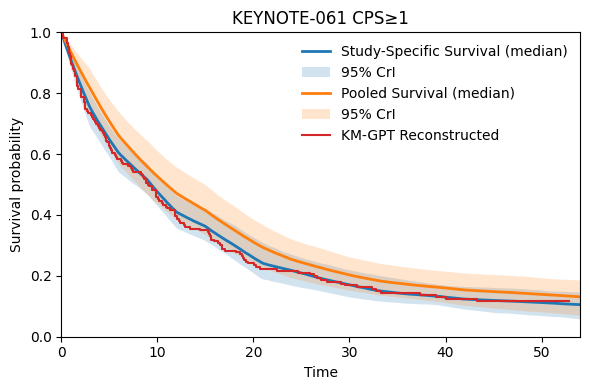

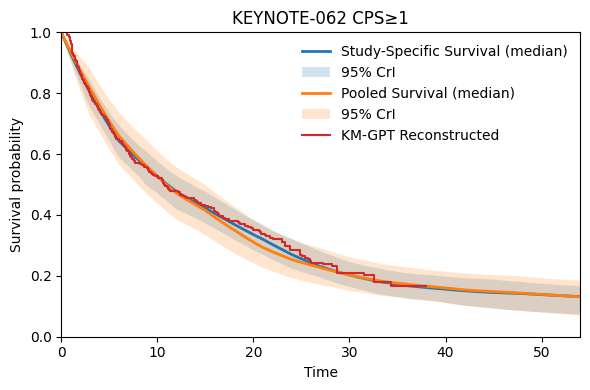

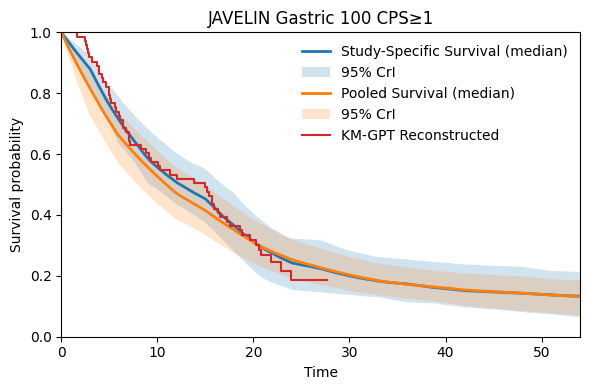

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Config / paths
# -----------------------------
exp_name   = "PDL1"
draws_path = data_path + f"draw_dict_{exp_name}_simplified_model_1.npz"
csv_path   = data_path + f"MARS_input_data_{exp_name}_1.csv"

# -----------------------------
# Load draws + rebuild dt
# -----------------------------
draws = np.load(draws_path, allow_pickle=True)   # needs 'a' and 'alpha'
df    = pd.read_csv(csv_path)

# studies and intervals
studies = np.sort(df["Group"].unique())          # trial IDs/names
S = len(studies)
intervals = np.sort(df["interval"].unique())
J = len(intervals)

# interval widths (dt) ordered by j=0..J-1
dt = (
    df.groupby(df["interval"].rank(method="dense").astype(int)-1)["deltaT"]
      .first().reindex(range(J)).to_numpy(dtype=float)
)
T_total = float(np.sum(dt))

# time grid for smooth curves
t_eval = np.linspace(0.0, T_total, 400)

# -----------------------------
# Helper: run anytime trial summary and save
# -----------------------------
def summarize_trial(trial_idx):
    summ = summarize_survival_anytime(
        input_data=draws,
        level='trial',
        study=int(trial_idx),
        t_eval=t_eval,
        rmst_grid=(6, 12, 24, 36)
    )
    return summ

# -----------------------------
# Plot each trial separately
# -----------------------------
t_eval = np.linspace(0.0, T_total, 400)
pooled_anytime = summarize_survival_anytime(
    input_data=draws,     # contains 'a' and 'alpha'
    level='pooled',
    t_eval=t_eval,
    rmst_grid=(6, 12, 24, 36)
)

# -----------------------------
# Plot (single chart, 95% CrI band)
# -----------------------------
time   = pooled_anytime["time"]
S_med  = pooled_anytime["S_q50"]
S_low  = pooled_anytime["S_q025"]
S_high = pooled_anytime["S_q975"]


nct_list = ['NCT02370498','NCT02494583','NCT02625610']
name_list = ['KEYNOTE-061', "KEYNOTE-062", 'JAVELIN Gastric 100']
group_label = ['Group1','Pembrolizumab','Avelumab']
for s_idx, s_name in enumerate(studies):
    summ = summarize_trial(s_idx)
    t  = summ["time"]
    m  = summ["S_q50"]
    lo = summ["S_q025"]
    hi = summ["S_q975"]

    df = pd.read_csv(data_path + nct_list[s_idx] + '_MT1_IPD.csv')
    treatment_df = df[df['Group'] == group_label[s_idx]]
    kmf = KaplanMeierFitter()
    kmf.fit(durations=treatment_df['time'], event_observed=treatment_df['status'])

    plt.figure(figsize=(6,4))
    # plt.fill_between(t, lo, hi, alpha=0.2, label="95% CrI")
    plt.plot(t, m, linewidth=2, label="Study-Specific Survival (median)")
    plt.fill_between(t, lo, hi, alpha=0.2, label="95% CrI")

    # plt.fill_between(time, S_low, S_high, alpha=0.2, label="95% CrI")
    plt.plot(time, S_med, linewidth=2, label="Pooled Survival (median)")
    plt.fill_between(time, S_low, S_high, alpha=0.2, label="95% CrI")

    kmf.plot_survival_function(ci_show=False, color='C3', label='KM-GPT Reconstructed', linestyle='-')

    plt.xlabel("Time")
    plt.ylabel("Survival probability")
    plt.ylim(0, 1.0)
    plt.xlim(t.min(), t.max())
    # plt.title(f"Trial {nct_list[s_idx]}")
    plt.title(f"{name_list[s_idx]} CPS≥1")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# 10

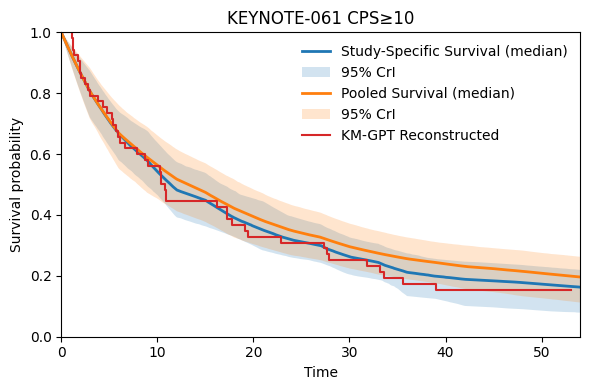

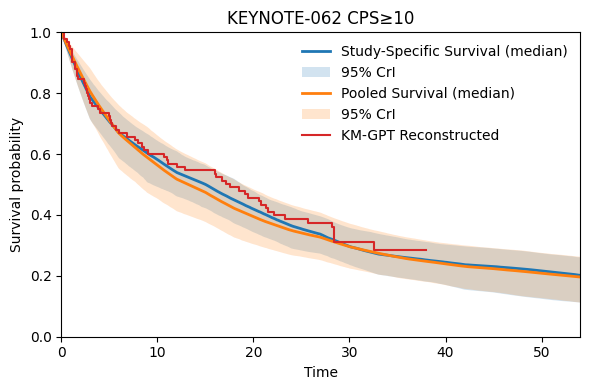

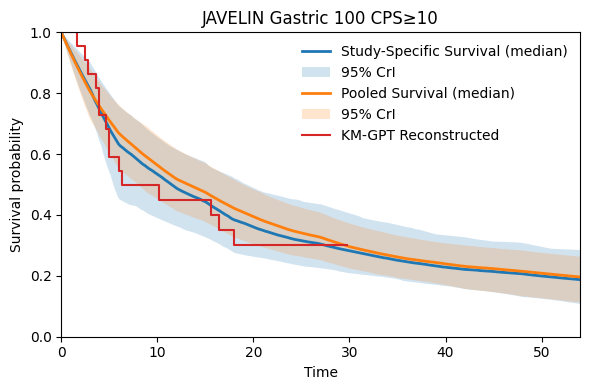

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Config / paths
# -----------------------------
exp_name   = "PDL1"
draws_path = data_path + f"draw_dict_{exp_name}_simplified_model_10.npz"
csv_path   = data_path + f"MARS_input_data_{exp_name}_10.csv"

# -----------------------------
# Load draws + rebuild dt
# -----------------------------
draws = np.load(draws_path, allow_pickle=True)   # needs 'a' and 'alpha'
df    = pd.read_csv(csv_path)

# studies and intervals
studies = np.sort(df["Group"].unique())          # trial IDs/names
S = len(studies)
intervals = np.sort(df["interval"].unique())
J = len(intervals)

# interval widths (dt) ordered by j=0..J-1
dt = (
    df.groupby(df["interval"].rank(method="dense").astype(int)-1)["deltaT"]
      .first().reindex(range(J)).to_numpy(dtype=float)
)
T_total = float(np.sum(dt))

# time grid for smooth curves
t_eval = np.linspace(0.0, T_total, 400)

# -----------------------------
# Helper: run anytime trial summary and save
# -----------------------------
def summarize_trial(trial_idx):
    summ = summarize_survival_anytime(
        input_data=draws,
        level='trial',
        study=int(trial_idx),
        t_eval=t_eval,
        rmst_grid=(6, 12, 24, 36)
    )
    return summ

# -----------------------------
# Plot each trial separately
# -----------------------------

pooled_anytime = summarize_survival_anytime(
    input_data=draws,     # contains 'a' and 'alpha'
    level='pooled',
    t_eval=t_eval,
    rmst_grid=(6, 12, 24, 36)
)

# -----------------------------
# Plot (single chart, 95% CrI band)
# -----------------------------
time   = pooled_anytime["time"]
S_med  = pooled_anytime["S_q50"]
S_low  = pooled_anytime["S_q025"]
S_high = pooled_anytime["S_q975"]

nct_list = ['NCT02370498','NCT02494583','NCT02625610']
name_list = ['KEYNOTE-061', "KEYNOTE-062", 'JAVELIN Gastric 100']
group_label = ['Group1','Group1','Avelumab']
for s_idx, s_name in enumerate(studies):
    summ = summarize_trial(s_idx)
    t  = summ["time"]
    m  = summ["S_q50"]
    lo = summ["S_q025"]
    hi = summ["S_q975"]

    df = pd.read_csv(data_path + nct_list[s_idx] + '_MT10_IPD.csv')
    treatment_df = df[df['Group'] == group_label[s_idx]]
    kmf = KaplanMeierFitter()
    kmf.fit(durations=treatment_df['time'], event_observed=treatment_df['status'])

    plt.figure(figsize=(6,4))
    # plt.fill_between(t, lo, hi, alpha=0.2, label="95% CrI")
    plt.plot(t, m, linewidth=2, label="Study-Specific Survival (median)")
    plt.fill_between(t, lo, hi, alpha=0.2, label="95% CrI")

    # plt.fill_between(time, S_low, S_high, alpha=0.2, label="95% CrI")
    plt.plot(time, S_med, linewidth=2, label="Pooled Survival (median)")
    plt.fill_between(time, S_low, S_high, alpha=0.2, label="95% CrI")

    kmf.plot_survival_function(ci_show=False, color='C3', label='KM-GPT Reconstructed', linestyle='-')

    plt.xlabel("Time")
    plt.ylabel("Survival probability")
    plt.ylim(0, 1.0)
    plt.xlim(t.min(), t.max())
    plt.title(f"{name_list[s_idx]} CPS≥10")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# Overall Figure

In [7]:
# --- Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load posterior draws for group 1
draws_1 = np.load(data_path + f'draw_dict_PDL1_simplified_model_1.npz', allow_pickle=True)
data_1 = pd.read_csv(data_path + f'MARS_input_data_PDL1_1.csv')

# Load posterior draws for group 10
draws_10 = np.load(data_path + f'draw_dict_PDL1_simplified_model_10.npz', allow_pickle=True)
data_10 = pd.read_csv(data_path + f'MARS_input_data_PDL1_10.csv')

studies = np.sort(data_10["Group"].unique())

# Extract interval widths (dt) for group 1
intervals_1 = np.sort(data_1["interval"].unique())
dt_1 = (
    data_1.groupby(data_1["interval"].rank(method="dense").astype(int)-1)["deltaT"]
        .first().reindex(range(len(intervals_1))).to_numpy(dtype=float)
)
T_total_1 = float(np.sum(dt_1))

# Extract interval widths (dt) for group 10
intervals_10 = np.sort(data_10["interval"].unique())
dt_10 = (
    data_10.groupby(data_10["interval"].rank(method="dense").astype(int)-1)["deltaT"]
        .first().reindex(range(len(intervals_10))).to_numpy(dtype=float)
)
T_total_10 = float(np.sum(dt_10))

# Time grid for smooth curves
t_eval_1 = np.linspace(0.0, T_total_1, 400)
t_eval_10 = np.linspace(0.0, T_total_10, 400)

# Summarize pooled survival for group 1
pooled_anytime_1 = summarize_survival_anytime(
    input_data=draws_1,
    level='pooled',
    t_eval=t_eval_1,
    rmst_grid=(12, 24, 36, 48)
)

# Summarize pooled survival for group 10
pooled_anytime_10 = summarize_survival_anytime(
    input_data=draws_10,
    level='pooled',
    t_eval=t_eval_10,
    rmst_grid=(12, 24, 36, 48)
)


# --- If 'taus' wasn't already defined, infer it from the RMST dicts
rmst_by_tau_1 = pooled_anytime_1["RMST_draws_by_tau"]
rmst_by_tau_10 = pooled_anytime_10["RMST_draws_by_tau"]


taus = sorted(set(rmst_by_tau_1.keys()).intersection(set(rmst_by_tau_10.keys())))

# Flatten into a DataFrame
rmst_data = []
for tau in taus:
    for val in rmst_by_tau_1[tau]:
        rmst_data.append({"RMST": val, "Group": "Group 1", "Tau": tau})
    for val in rmst_by_tau_10[tau]:
        rmst_data.append({"RMST": val, "Group": "Group 10", "Tau": tau})

rmst_df = pd.DataFrame(rmst_data)

# ========================
# Panel A: Survival curves
# ========================
time_1   = pooled_anytime_1["time"]
S_med_1  = pooled_anytime_1["S_q50"]
S_lo_1   = pooled_anytime_1["S_q025"]
S_hi_1   = pooled_anytime_1["S_q975"]

time_10  = pooled_anytime_10["time"]
S_med_10 = pooled_anytime_10["S_q50"]
S_lo_10  = pooled_anytime_10["S_q025"]
S_hi_10  = pooled_anytime_10["S_q975"]

# ==========================
# Panel B: RMST boxplot prep
# ==========================
# We’ll plot horizontal boxplots at y = tau, with a small vertical offset
# so Group 1 and Group 10 sit side-by-side at each τ.
offset = 0.35

# Build arrays and positions for matplotlib.boxplot
box_data = []      # sequence of arrays
positions = []     # matching y positions
colors = []        # for patch coloring
labels = []        # for legend handles

for i, tau in enumerate(taus):
    # Group 1 at tau
    box_data.append(np.asarray(rmst_by_tau_1[tau], dtype=float))
    positions.append(tau + offset)
    colors.append("C1")
    labels.append("Group 1")

    # Group 10 at tau
    box_data.append(np.asarray(rmst_by_tau_10[tau], dtype=float))
    positions.append(tau - offset)
    colors.append("C0")
    labels.append("Group 10")

C:\Users\User\AppData\Local\Temp\ipykernel_44168\4256871272.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


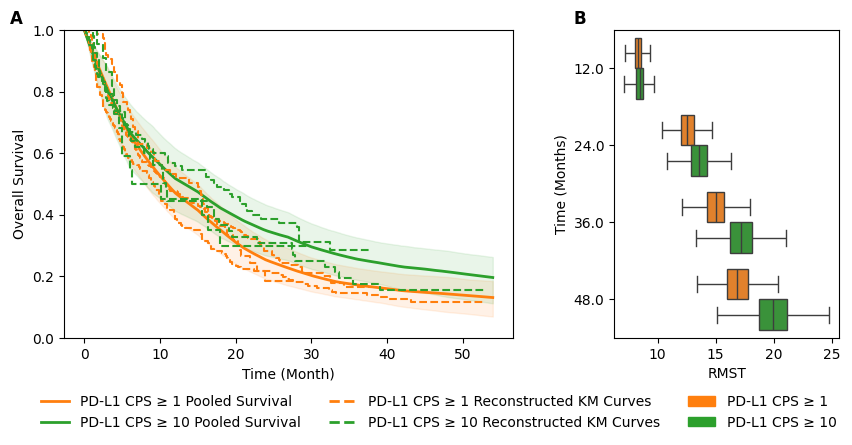

In [8]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

fig = plt.figure(figsize=(10, 4))
# ---- Panel A
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1], wspace=0.3)
ax1 = fig.add_subplot(gs[0, 0])

# Group 1 (orange-ish, C1)
ax1.fill_between(time_1, S_lo_1, S_hi_1, alpha=0.1, color="C1")
ax1.plot(time_1, S_med_1, lw=2, color="C1", label="PD-L1 CPS ≥ 1")

# Group 10 (teal-ish, C2)
ax1.fill_between(time_10, S_lo_10, S_hi_10, alpha=0.1, color="C2")
ax1.plot(time_10, S_med_10, lw=2, color="C2", label="PD-L1 CPS ≥ 10")

nct_list = ['NCT02370498','NCT02494583','NCT02625610']
group_label = ['Group1','Pembrolizumab','Avelumab']
for s_idx, s_name in enumerate(studies):
    summ = summarize_trial(s_idx)
    t  = summ["time"]
    m  = summ["S_q50"]
    lo = summ["S_q025"]
    hi = summ["S_q975"]

    df = pd.read_csv(data_path + nct_list[s_idx] + '_MT1_IPD.csv')
    treatment_df = df[df['Group'] == group_label[s_idx]]
    kmf = KaplanMeierFitter()
    kmf.fit(durations=treatment_df['time'], event_observed=treatment_df['status'])

    kmf.plot_survival_function(ci_show=False, color='C1', label=f'KM {s_name}', linestyle='--', ax=ax1)

nct_list = ['NCT02370498','NCT02494583','NCT02625610']
group_label = ['Group1','Group1','Avelumab']
for s_idx, s_name in enumerate(studies):
    summ = summarize_trial(s_idx)
    t  = summ["time"]
    m  = summ["S_q50"]
    lo = summ["S_q025"]
    hi = summ["S_q975"]

    df = pd.read_csv(data_path + nct_list[s_idx] + '_MT10_IPD.csv')
    treatment_df = df[df['Group'] == group_label[s_idx]]
    kmf = KaplanMeierFitter()
    kmf.fit(durations=treatment_df['time'], event_observed=treatment_df['status'])
    kmf.plot_survival_function(ci_show=False, color='C2', label=f'KM {s_name}', linestyle='--', ax=ax1)

ax1.set_xlabel("Time (Month)")
ax1.set_ylabel("Overall Survival")
ax1.set_ylim(0, 1.0)
ax1.text(-0.12, 1.02, "A", transform=ax1.transAxes, fontsize=12, fontweight="bold")
ax1.legend().remove()

# ---- Panel B: RMST boxplot with seaborn
ax2 = fig.add_subplot(gs[0, 1])

sns.boxplot(
    data=rmst_df,
    x="RMST", y="Tau",
    hue="Group",
    orient="h",
    showfliers=False,
    ax=ax2,
    palette={"Group 1": "C1", "Group 10": "C2"},
    legend=False
)

ax2.set_ylabel("Time (Months)")
ax2.set_xlabel("RMST")
ax2.text(-0.18, 1.02, "B", transform=ax2.transAxes, fontsize=12, fontweight="bold")

# ==========================
# Shared legend at bottom
# ==========================
# --- Manual line handles (for survival curves)
line_handles = [
    mlines.Line2D([], [], color="C1", lw=2, label="PD-L1 CPS ≥ 1 Pooled Survival"),
    mlines.Line2D([], [], color="C2", lw=2, label="PD-L1 CPS ≥ 10 Pooled Survival"),
    mlines.Line2D([], [], color="C1", lw=2, linestyle='--', label="PD-L1 CPS ≥ 1 Reconstructed KM Curves"),
    mlines.Line2D([], [], color="C2", lw=2, linestyle='--', label="PD-L1 CPS ≥ 10 Reconstructed KM Curves"),
]

# --- Manual box handles (for RMST boxplots)
box_handles = [
    mpatches.Patch(color="C1", label="PD-L1 CPS ≥ 1"),
    mpatches.Patch(color="C2", label="PD-L1 CPS ≥ 10")
]

# Merge them
handles = line_handles + box_handles
labels = [h.get_label() for h in handles]

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15)  # adjust vertical position
)

# Final adjustments
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# Median Survival

In [10]:
import numpy as np

def compute_median_OS(alpha_draws, interval_bounds):
    """
    Compute posterior samples of median survival times from piecewise exponential hazards.
    
    Parameters
    ----------
    alpha_draws : np.ndarray
        Shape (n_draws, J), posterior log-hazards for J intervals.
    interval_bounds : list or np.ndarray
        Length J+1 array giving the time boundaries of the piecewise intervals.

    Returns
    -------
    medians : np.ndarray
        Posterior samples of median survival times.
    """
    n_draws, J = alpha_draws.shape
    medians = np.zeros(n_draws)

    for d in range(n_draws):
        hazards = np.exp(alpha_draws[d, :])
        surv = 1.0
        for j in range(J):
            t0, t1 = interval_bounds[j], interval_bounds[j+1]
            lam = hazards[j]
            # survival at end of interval
            surv_end = surv * np.exp(-lam * (t1 - t0))
            if surv_end <= 0.5:
                # solve for exact crossing time
                dt = (np.log(surv) - np.log(0.5)) / lam
                medians[d] = t0 + dt
                break
            surv = surv_end
        else:
            # survival never drops below 0.5
            medians[d] = np.inf
    return medians


# Example: load posterior draws for CPS ≥1 and CPS ≥10
draws_1  = np.load(data_path + "draw_dict_PDL1_simplified_model_1.npz")
draws_10 = np.load(data_path + "draw_dict_PDL1_simplified_model_10.npz")

# Assume interval boundaries (from your data setup)
data = pd.read_csv(data_path + f'MARS_input_data_PDL1_10.csv')
interval_bounds = np.sort(data["interval"].unique())-1
interval_bounds = np.append(interval_bounds, interval_bounds[-1] + (interval_bounds[1]-interval_bounds[0]))
interval_bounds = interval_bounds*3

# Median OS posterior samples
meds_1  = compute_median_OS(draws_1["a"], interval_bounds)
meds_10 = compute_median_OS(draws_10["a"], interval_bounds)

# Summarize with median and 95% CrI
def summarize(meds):
    # meds = meds[~np.isnan(meds)]
    return np.median(meds), np.percentile(meds, 2.5), np.percentile(meds, 97.5)

median_1, lo_1, hi_1   = summarize(meds_1)
median_10, lo_10, hi_10 = summarize(meds_10)

print(f"CPS ≥1:  median OS = {median_1:.2f} months (95% CrI {lo_1:.2f}, {hi_1:.2f})")
print(f"CPS ≥10: median OS = {median_10:.2f} months (95% CrI {lo_10:.2f}, {hi_10:.2f})")


CPS ≥1:  median OS = 10.93 months (95% CrI 7.97, 14.95)
CPS ≥10: median OS = 13.23 months (95% CrI 7.98, 18.94)
